# 6.5.2 激励与可辨识范围

## 学习目标与先修知识

能根据回归矩阵（matrix）的秩（rank）判断两个自由系数能否被这组理想记录区分；用条件数（condition number）解释近似参数（parameter）混淆；区分实验激励（excitation）、观测（observation）时段与已知物理约束的作用。

先修：[ARX 回归与两种预测](01-ARX回归与两种预测.ipynb)、线性方程和特征值（eigenvalue）、[最小二乘](../04-最小二乘与参数估计/01-最小二乘与误差假设.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

给组织维持同一个输入（input），等到浓度（concentration）稳定后连续测量一百次。许多重复值能否分别告诉我们“记忆系数”和“输入增益（gain）”？如果改为从偏离稳态的位置开始，输入仍保持常量，答案会改变吗？关键不只是数据行数，而是这些行是否提供新的参数约束。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE,PINK,GRAY='#008bfb','#ff0051','#555555'

## 初步实验

In [2]:
candidates=[(.5,1.),(.8,.4),(.9,.2)]
display(Markdown(show_table(['a / 1','b / (U/V)','输入 1 V 时的稳态 / U'],[(a,b,b/(1-a)) for a,b in candidates])))

| a / 1 | b / (U/V) | 输入 1 V 时的稳态 / U |
| --- | --- | --- |
| 0.5 | 1 | 2 |
| 0.8 | 0.4 | 2 |
| 0.9 | 0.2 | 2 |

## 模型假设

比较同一个离散候选模型（model） $y_{n+1}=a y_n+b u_n$，$a,b$ 均为独立未知系数；$y$ 单位 U，$u$ 单位 V，$a$ 无量纲（dimensionless），$b$ 单位 U/V，时间间隔固定为 1 T。先用无噪、完整观测分析代数可辨识性（identifiability）；随后添加小扰动，检查估计对读数变化的敏感性。

## 数学解释与推导

### 稳态只能提供一条方程，但常输入不总是这样

在 $|a|<1$、$u_n=u^*$ 下，稳态 $y^*=a y^*+b u^*$，即 $y^*/u^*=b/(1-a)$（此处 $u^*\ne0$）。若每行都是 $[y^*,u^*]$，两列成比例，重复多少次也仍只有一个独立方向。不同的 $(a,b)$ 可以给出同一稳态。

从非稳态初值（initial condition）出发，常输入下 $y_n=y^*+a^n(y_0-y^*)$。只要有不同的 $y_n$，且常输入非零，至少两行 $[y_j,u^*],[y_k,u^*]$ 的行列式（determinant）为 $u^*(y_j-y_k)\ne0$，就能提供两个方向。因此“常输入永远不能辨识”是错误的；只记录已经衰减消失的瞬态，才会丢失这部分信息。若 $u^*=0$，输入列全零，仍无法由这次实验单独确定 $b$。

### 精确秩与数值敏感性

记两列为向量（vector） $v=(y_n)$、$w=(u_n)$，则

$$\Phi^\mathsf{T}\Phi=\begin{pmatrix}Y&C\\C&U\end{pmatrix},\quad
Y=\sum y_n^2,\quad U=\sum u_n^2,\quad C=\sum y_nu_n.$$

两列全零时秩为 0；$YU-C^2>0$ 时秩为 2；其余非零情形秩为 1。这个判定在小整数上可精确执行；浮点数据若两列几乎平行，直接比较一个接近 0 的差容易受消减误差影响。

奇异值（singular value）是 $\Phi^\mathsf{T}\Phi$ 特征值的非负平方根。对实测数值，可以用奇异值分解（singular value decomposition，SVD）检查不同参数方向被放大多少。范数（norm）取二范数时，满列秩矩阵的条件数为最大与最小奇异值的比值 $\kappa=\sigma_{\max}/\sigma_{\min}$；若最小奇异值为零（列秩不足），则约定条件数为无穷大。两列满秩却几乎平行时，$\sigma_{\min}$ 很小，某个参数方向对观测影响微弱，微小扰动也能使估计变化很大。

数值大小还随列的单位缩放变化；下面同时报告原始量纲（dimension）下的矩阵与每列除以其长度后的条件数。缩放能改善算术表现，不能创造丢失的独立方向。求解器精度也不能替代新实验；新的输入模式、可观测瞬态或额外观测通道可能增加信息，但是否足够要按候选模型检验。

### 哪些参数已经知道，必须先说明

这里先另用流率（flow rate） $q$（单位 U/T）表示物质输入，避免与前文的刺激 $u$（单位 V）混淆。连续单室模型（one-compartment model） $\dot A=q-kA$ 在 $k>0$ 时有 $A^*=q/k$。若 $q$ 已独立校准且 $A^*>0$，理想模型内 $k=q/A^*$ 已可确定，不能套用“两参数未知”的混淆结论。若 $q,k$ 都未知，或保留刺激输入、模型实际为 $\dot A=g u-kA$，其中 $g$ 单位 U/(V·T)，且 $g,k$ 都未知，稳态一般只约束一个比值。

对刺激输入且已知有量纲增益 $g$，精确采样（sampling）的物理约束把 $a=e^{-kh}$ 与 $b=g(1-e^{-kh})/k$ 联系起来，$b$ 单位仍为 U/V；改用流率 $q$ 时，其系数为 $(1-e^{-kh})/k$，单位为 T。将 $a,b$ 当两个独立未知量是更宽的参数化，它的可辨识结论不能无条件替代这个单参数物理模型。

## 核心实现

小整数题目使用精确算术判秩；真实数值轨迹（trajectory）用 SVD 和明确容差。

In [3]:
def regressor_rank(states,inputs):
    yy=sum(y*y for y in states);uu=sum(u*u for u in inputs)
    yu=sum(y*u for y,u in zip(states,inputs))
    if yy+uu==0:return 0
    return 2 if yy*uu-yu*yu>0 else 1

def simulate(a,b,initial,inputs):
    values=[float(initial)]
    for u in inputs:values.append(a*values[-1]+b*u)
    return np.array(values)

def numerical_directions(matrix):
    singular=np.linalg.svd(matrix,compute_uv=False)
    tolerance=max(matrix.shape)*np.finfo(float).eps*singular[0]
    rank=int(np.sum(singular>tolerance))
    condition=float(singular[0]/singular[-1]) if rank==matrix.shape[1] else float('inf')
    lengths=np.linalg.norm(matrix,axis=0)
    scaled=matrix/np.where(lengths==0,1,lengths)
    scaled_singular=np.linalg.svd(scaled,compute_uv=False)
    scaled_condition=float(scaled_singular[0]/scaled_singular[-1]) if rank==matrix.shape[1] else float('inf')
    return rank,condition,scaled_condition

## 对照实验

四次确定性记录使用同一参数 a=0.8、b=0.4，只改变初始状态（state）或预定输入。四组记录均按确定性规则生成。

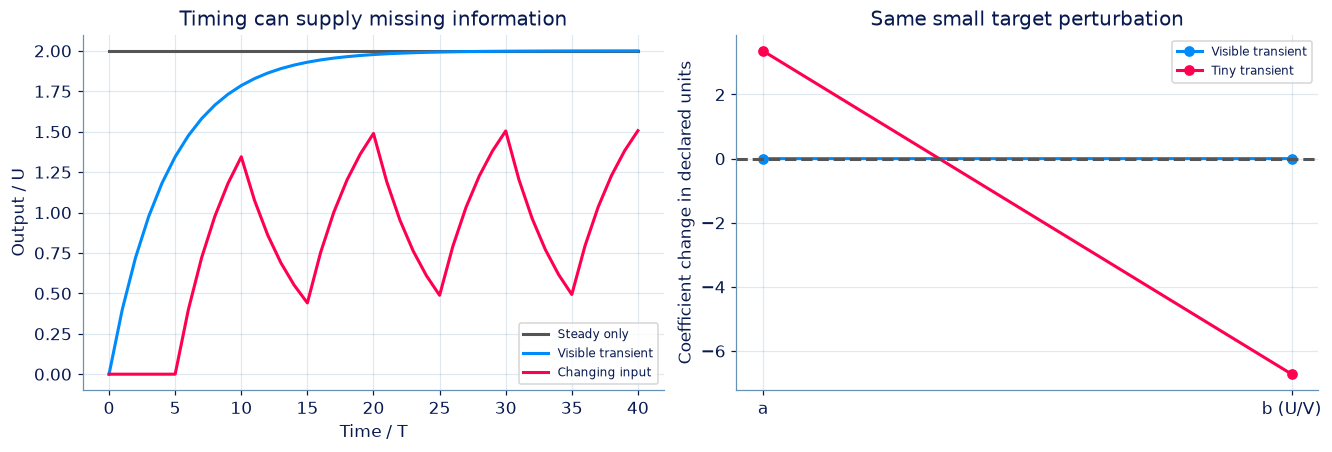

| 实验 | 数值秩 | 原单位条件数 | 列归一条件数 |
| --- | --- | --- | --- |
| Steady only | 1 | inf | inf |
| Visible transient | 2 | 9.1099 | 7.67359 |
| Tiny transient | 2 | 2.15518e+06 | 1.72415e+06 |
| Changing input | 2 | 2.42312 | 2.30005 |

In [4]:
N=40;constant=np.ones(N);changing=np.where((np.arange(N)//5)%2,1.,0.)
cases=[('Steady only',2.,constant),('Visible transient',0.,constant),('Tiny transient',2.+1e-5,constant),('Changing input',0.,changing)]
rows=[];records=[]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for label,initial,u in cases:
    y=simulate(.8,.4,initial,u);matrix=np.column_stack([y[:-1],u])
    rank,condition,scaled_condition=numerical_directions(matrix)
    rows.append([label,rank,condition,scaled_condition]);records.append((label,y,u,matrix))
for label,y,u,matrix in [records[0],records[1],records[3]]:
    color={'Steady only':GRAY,'Visible transient':BLUE,'Changing input':PINK}[label]
    axes[0].plot(np.arange(N+1),y,color=color,label=label)
axes[0].set(xlabel='Time / T',ylabel='Output / U',title='Timing can supply missing information');axes[0].legend(fontsize=8)
for label,y,u,matrix in [records[1],records[2]]:
    delta=1e-4*np.sin(np.arange(N))
    original=np.linalg.lstsq(matrix,y[1:],rcond=None)[0]
    perturbed=np.linalg.lstsq(matrix,y[1:]+delta,rcond=None)[0]
    color=BLUE if label=='Visible transient' else PINK
    axes[1].plot([0,1],perturbed-original,'o-',color=color,label=label)
axes[1].axhline(0,color=GRAY,ls='--');axes[1].set(xticks=[0,1],xticklabels=['a','b (U/V)'],ylabel='Coefficient change in declared units',title='Same small target perturbation');axes[1].legend(fontsize=8)
plt.show()
display(Markdown(show_table(['实验','数值秩','原单位条件数','列归一条件数'],rows)))

## 结果解释

稳态记录只留下一个方向；常输入的可见瞬态与变化输入都可以给出满秩记录。极小瞬态也可数学满秩，但加入同样的微小目标扰动后参数变化更大。这个演示单独扰动回归目标以检查病态性；它不是完整测量噪声（measurement noise）模型，上一节的误差变量偏差仍需另外检查。

对当前两列回归矩阵，输入变化和初始暂态（transient）都可能增加独立方向。结合秩与条件数，可以判断这些记录是否足以区分两个系数。

### 独立核对

手算整数矩阵的三个秩边界；用第一、第二次无噪转移直接恢复参数，核对常输入瞬态结论；最后分别核对自由系数和已知输入的物理参数约束。

In [5]:
assert regressor_rank([0,0],[0,0])==0
assert regressor_rank([2,2,2],[1,1,1])==1
assert regressor_rank([0,1,2],[1,1,1])==2
for label,y,u,matrix in [records[1],records[3]]:
    np.testing.assert_allclose(np.linalg.lstsq(matrix,y[1:],rcond=None)[0],[.8,.4],atol=2e-14)
y=records[1][1];b_direct=y[1];a_direct=(y[2]-b_direct)/y[1]
np.testing.assert_allclose([a_direct,b_direct],[.8,.4])
np.testing.assert_allclose([b/(1-a) for a,b in candidates],2.)
known_input=3.;equilibrium=6.;clearance=known_input/equilibrium
np.testing.assert_allclose(known_input-clearance*equilibrium,0.)
assert rows[2][2]>1000*rows[1][2]
print('秩边界、瞬态闭式恢复、稳态比值与已知物理输入检查通过。')

秩边界、瞬态闭式恢复、稳态比值与已知物理输入检查通过。


## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：给定实验能区分几个回归方向

ARX回归矩阵（matrix）的两列分别是给定states与inputs。输入（input）为小整数，请用精确算术求矩阵秩（rank）。

**函数与代码模板**

```python
def solve(
    states: list[int],
    inputs: list[int],
) -> int:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[int]` | 每行的上一拍状态（state）或输出（output）。 | U |
| `inputs` | `list[int]` | 同一行的当前输入。 | V |

**返回值**

直接返回 rank（int）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rank` | `int` | 两列矩阵的秩，只能是0、1或2。 | 1 |

**计算规则**

令Y=Σstates²、U=Σinputs²、C=Σstates*inputs。两列全零时rank=0；Y*U−C²>0时rank=2；其他情况rank=1。本题全为整数，可精确判断，不设置浮点秩阈值。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 两列表等长1—50，各项整数绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | 每行的上一拍状态（state）或输出（output）。 | [2, 2, 2] | U |
| inputs | 同一行的当前输入。 | [1, 1, 1] | V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [2, 2, 2]
inputs = [1, 1, 1]

result = solve(states, inputs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rank | 两列矩阵的秩，只能是0、1或2。 | 1 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 1
```

**样例解释**

恒定稳态列 [2,2,2] 是输入列的2倍，秩为1，只约束参数（parameter）组合，不能独立确定两个自由系数。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：给定实验能区分几个回归方向](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-excitation-rank)

### 第 2 题 · 多项选择题：只在稳态能确定什么

ARX中a、b是两个独立未知参数（parameter），|a|<1；只测到非零恒定输入（input）u*=1 V下稳态y*=2 U。哪些正确？

- **A.** 只能约束b/(1−a)=2 U/V。
- **B.** (a,b)=(0.5,1)和(0.8,0.4)都符合这条关系。
- **C.** 已知输入值就必能独立确定a、b。
- **D.** 动态过渡或新的激励可能增加可辨识信息。

[作答：只在稳态能确定什么](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-steady-confounding)

### 第 3 题 · 单项选择题：常量输入一定无法辨识吗

输入（input）恒定，但从非平衡（equilibrium）初态出发并记录了完整过渡。哪项正确？

- **A.** 变化中的输出（output）列可能不与常量输入列成比例，有限样本回归矩阵（matrix）可能满秩（rank）。
- **B.** 所有瞬态都必然提供高精度参数（parameter）估计。
- **C.** 只需数值矩阵满秩就不必检查噪声模型（model）。
- **D.** 常量输入在任何情况下都只能得到秩1。

[作答：常量输入一定无法辨识吗](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-constant-transient)

### 第 4 题 · 多项选择题：满秩为什么仍可能很难估计

两个回归列几乎成比例，矩阵（matrix）仍数学满秩（rank）。哪些正确？

- **A.** 秩为2就意味着参数（parameter）误差为0。
- **B.** 用数值稳定的最小二乘可以缓解算术误差，却不能创造信息。
- **C.** 微小观测（observation）扰动可能造成很大的参数变化。
- **D.** 应检查奇异值（singular value）比例或条件数（condition number），并考虑新的实验设计。

[作答：满秩为什么仍可能很难估计](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-conditioning)

### 第 5 题 · 多项选择题：同一稳态结论依赖哪些未知量

连续单室稳态A*=u/k、k>0。哪些判断正确？

- **A.** 不论参数（parameter）哪些已知，稳态永远不能提供k信息。
- **B.** 若u与k都未知，只观测（observation）A*一般不能分别确定二者。
- **C.** 若u已独立校准且A*>0，则理想模型（model）内k=u/A*可确定。
- **D.** 若u已知且非零，输入（input）通道还有未知增益（gain）g，A*=g*u/k只约束g/k。

[作答：同一稳态结论依赖哪些未知量](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-mechanistic-parameters)

**进一步阅读**

[Ljung 第二版资料页](https://www.rt.isy.liu.se/en/books/sysid/)：模型可辨识性与实验设计；[Stanford 应用线性代数教材](https://web.stanford.edu/~boyd/vmls/)：最小二乘与矩阵方向的补充。